# CS 6220 HW2, Part 3: Regression Tree
Daniel Cho (003182370)

This notebook is self-contained. It rebuilds the data exactly as in Parts 1 and 2 (`hw2_6220_chodaniel.ipynb`) and then implements and evaluates a regression tree from scratch.

**Structure** (sections follow the report questions in order)
* **Setup:** the data generator (Part 1), linear regression (Part 2, the baseline for Q10), and the datasets shared by Q9–Q10
* **Q8:** tree pseudo-code, AI prompts, and the implementation, one cell per pseudo-code function (`Node`, `split_data`, `split_score`, `is_leaf`, `expand_node`, `RegressionTree.fit / predict / visualize`)
* **Q9:** tree fits for all 24 setups
* **Q10:** trees vs. linear regression: who wins, then (i) extra columns, (ii) tree size, (iii) noise
* **Q11:** overfitting study on sin(2πx)
* **Q12:** hyper-parameters

**AI usage:** Parts 1 and 2 are hand-written. Part 3 was built with AI assistance; the prompts are listed under Q8.

In [1]:
import random
import math
from collections import deque

import numpy as np
from numpy.linalg import inv
import pandas as pd
import matplotlib.pyplot as plt

## Setup 1: Data generator (from Part 1)

In [2]:
def generate_noisy_dataset(list_func, true_func, x_range, n_samples: int, epsilon=0.1):
    '''Each record is [x, f_1(x), ..., f_d(x), true_func(x) + noise], with noise ~ U[-epsilon, epsilon].'''
    record = []

    for i in range(n_samples):
        curr_iter = []
        x = round(random.uniform(x_range[0], x_range[1]), 3)
        curr_iter.append(x)
        noise = round(random.uniform(-epsilon, epsilon), 3)

        for func in list_func:
            curr_iter.append(round(func(x), 3))
        curr_iter.append(round(noise + true_func(x), 3))
        record.append(curr_iter)
    return record


def split_train_test(data):
    split = int(len(data) * 0.8)
    return data[:split], data[split:]

## Setup 2: Linear regression (from Part 2, the baseline for Q10)

In [3]:
def calc_weight(trainX, trainY):
    XTXinv = inv(np.dot(np.transpose(trainX), trainX)) # (X^T * X)^-1
    XTY = np.dot(np.transpose(trainX), trainY)      # X^T * Y
    return np.dot(XTXinv, XTY)


def pred(betas, test_X):
    return betas @ test_X.T


def rmse(preds, gt):
    return np.sqrt(np.mean((preds - gt)**2))


def with_ones(D):
    # split a dataset into (X with a leading column of 1s, y)
    return np.column_stack([np.ones(len(D)), D[:, :-1]]), D[:, -1]

## Setup 3: Datasets for Q9–Q10
Q9 and Q10 use the same datasets as the linear-regression experiments: x in [0, 1], 1000 records, true functions linear $2x+1$ and cubic $0.5x^3 - x^2 + x$, noise $\varepsilon \in \{0.01, 0.1\}$, and schemas $(x,y)$ and $(x,x^2,x^3,y)$.

The seed is reset before every call, so both schemas of a dataset share the same x values and the same noise, and the 80/20 split is identical on every run.

In [4]:
SEED = 6220
true_funcs = {'linear': lambda x: 2*x + 1,
              'cubic':  lambda x: 0.5*x**3 - x**2 + x}
noise_levels = [0.01, 0.1]
schemas = {'(x,y)': [],
           '(x,x²,x³,y)': [lambda x: x**2, lambda x: x**3]}

datasets = {}
for fname, f in true_funcs.items():
    for eps in noise_levels:
        for sname, funcs in schemas.items():
            random.seed(SEED)
            data = np.array(generate_noisy_dataset(funcs, f, [0.0, 1.0], 1000, eps))
            datasets[(fname, eps, sname)] = split_train_test(data)

train, test = datasets[('cubic', 0.1, '(x,x²,x³,y)')]
print(train.shape, test.shape)
train[:3]

(800, 4) (200, 4)


array([[0.643, 0.413, 0.266, 0.407],
       [0.262, 0.069, 0.018, 0.145],
       [0.977, 0.955, 0.933, 0.407]])

## Q8: Pseudo-code for the regression tree
> *Show the pseudo-code for the tree. If you used AI to generate code, include all the major prompts. They should correspond to the main functions in the pseudo-code.*

The tree is built with the work-queue algorithm from the lecture. Each node covers a subset $D$ of the training data. Impurity is the sum of squared errors, $\text{SSE}(D) = \sum_{r \in D} (y_r - \bar{y}_D)^2$, and a leaf predicts the mean $\bar{y}_D$.

```
fit(dataset D, min_records):
    root = new Node;  work_Q.add(root, D)
    while work_Q not empty:
        (N, D) = work_Q.remove_next()
        if is_leaf(D):
            N.set_prediction(D)                         # mean of y in D
        else:
            (N1, D1), (N2, D2) = expand_node(N, D)
            N.set_children(N1, N2)
            work_Q.add(N1, D1);  work_Q.add(N2, D2)

is_leaf(D):   |D| < min_records  OR  all rows of D have identical inputs

expand_node(N, D):
    for each attribute A in D:
        for each distinct value v of D.A (except the largest):
            compute split_score(D, A, v)
    (A_max, v_max) = split with greatest score
    N.set_split(A_max, v_max)
    (D1, D2) = split_data(D, A_max, v_max)
    return (new Node, D1), (new Node, D2)

split_data(D, A, v):    D1 = {r in D : r.A <= v},  D2 = D - D1
split_score(D, A, v):   SSE(D) - SSE(D1) - SSE(D2)      # impurity reduction

predict(x):
    N = root
    while N is not a leaf:  N = N.left if x[N.A] <= N.v else N.right
    return N.prediction
```

**Major AI prompts** (as actually used):
1. *"...create the Node class which will make up the Regression Tree... what features I should add to it outside of the typical self.value, self.left, self.right. What else do I need to do before implementing fit()?"* This gave the `Node` fields (split attribute and value, children, prediction) and a step-by-step plan that maps the lecture pseudo-code to functions.
2. *"Is this not it or am I missing something?"* (my `split_data` returned `D[:A], D[:A]`), then *"give me code"*. This gave the boolean-mask version of `split_data`.
3. *"give code for split_score"*. This gave the SSE-reduction `split_score`.
4. *"Create a whole separate notebook, building and using the data the same way as we did in part 1/2, but building out part 3 of the homework specification entirely"* (with the HW spec pasted). This gave `is_leaf`, `expand_node`, `fit`, `predict`, `visualize`, and the Q9–Q12 experiments, all following the pseudo-code above.

### Implementation (one cell per pseudo-code function)

**`Node`**: split predicate `(A, v)`, children, and prediction

In [5]:
class Node:
    def __init__(self):
        self.left = None
        self.right = None
        self.A = None           # split attribute (column index)
        self.v = None           # split value: row[A] <= v goes left
        self.prediction = None
        self.n_records = 0

    def set_split(self, A, v):
        self.A, self.v = A, v

    def set_children(self, N1, N2):
        self.left, self.right = N1, N2

    def set_prediction(self, D):
        self.prediction = D[:, -1].mean()
        self.n_records = len(D)

**`split_data`, `split_score`** (with SSE as `impurity`)

In [6]:
def impurity(y):
    return np.sum((y - np.mean(y)) ** 2)


def split_data(D, A, v):
    mask = D[:, A] <= v
    return D[mask], D[~mask]


def split_score(D, A, v):
    left, right = split_data(D, A, v)
    if len(left) == 0 or len(right) == 0:
        return -np.inf
    return impurity(D[:, -1]) - (impurity(left[:, -1]) + impurity(right[:, -1]))

**`is_leaf`, `expand_node`**

In [7]:
def is_leaf(D, min_records):
    # second check: every row has the same inputs, so no split can separate them
    return len(D) < min_records or np.all(D[:, :-1] == D[0, :-1])


def expand_node(N, D):
    best_score, A_max, v_max = -np.inf, None, None
    for A in range(D.shape[1] - 1):
        for v in np.unique(D[:, A])[:-1]:   # largest value would leave the right side empty
            score = split_score(D, A, v)
            if score > best_score:
                best_score, A_max, v_max = score, A, v
    N.set_split(A_max, v_max)
    D1, D2 = split_data(D, A_max, v_max)
    return (Node(), D1), (Node(), D2)

**`RegressionTree`**: `fit`, `predict`, `visualize`
* `fit(dataset, min_records)` takes rows `[x, f_1(x), ..., y]` and runs the work-queue loop. Because the queue is FIFO, the tree is built level by level.
* `predict(X)` takes rows `[x, f_1(x), ...]` without y and returns one prediction per row.
* `visualize(list_func)` evaluates the tree on a dense x-grid and draws the prediction line plus a gray vertical line at each split point. A split on an $x^2$ or $x^3$ column is drawn at the x where that column crosses the split value.

In [8]:
class RegressionTree:
    def fit(self, dataset, min_records):
        D = np.asarray(dataset, dtype=float)
        self.x_range = (D[:, 0].min(), D[:, 0].max())
        self.root = Node()
        work_Q = deque([(self.root, D)])
        while work_Q:
            N, D = work_Q.popleft()
            if is_leaf(D, min_records):
                N.set_prediction(D)
            else:
                (N1, D1), (N2, D2) = expand_node(N, D)
                N.set_children(N1, N2)
                work_Q.append((N1, D1))
                work_Q.append((N2, D2))
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X[:, None]   # a plain list of x values
        preds = np.empty(len(X))
        for i, row in enumerate(X):
            N = self.root
            while N.left is not None:
                N = N.left if row[N.A] <= N.v else N.right
            preds[i] = N.prediction
        return preds

    def nodes(self):
        stack, out = [self.root], []
        while stack:
            N = stack.pop()
            out.append(N)
            if N.left is not None:
                stack += [N.left, N.right]
        return out

    def leaf_sizes(self):
        return [N.n_records for N in self.nodes() if N.left is None]

    def visualize(self, list_func=(), ax=None, n_points=1000):
        ax = ax or plt.gca()
        xs = np.linspace(*self.x_range, n_points)
        X = np.column_stack([xs] + [[f(x) for x in xs] for f in list_func])
        for N in self.nodes():
            if N.left is not None:
                # x positions where "column A <= v" flips, so splits on x^2 / x^3 land at the right x
                for x_split in xs[1:][np.diff(X[:, N.A] <= N.v)]:
                    ax.axvline(x_split, color='gray', lw=0.5, alpha=0.4)
        ax.plot(xs, self.predict(X), color='red', lw=1.5, label='tree')
        return ax

Sanity check on a tiny dataset where the best split is known by hand ($x \le 2$, score $82 - (0.5 + 0.5) = 81$):

In [9]:
D = np.array([[1, 1], [2, 2], [3, 10], [4, 11]], dtype=float)
assert split_score(D, 0, 2) == 81.0 and split_score(D, 0, 4) == -np.inf
assert list(RegressionTree().fit(D, 3).predict([[1.5], [3.5]])) == [1.5, 10.5]
assert RegressionTree().fit(D, 5).leaf_sizes() == [4]
print('ok')

ok


## Q9: Train, test and evaluate the tree on every setup
> *For each combination, show a scatterplot of the training data and add to it a plot of the true function and the tree visualization: (a) the same training and test sets as for linear regression: true functions [linear, cubic], noise levels [0.01, 0.1], schemas [(x,y), (x,x²,x³,y)]; (b) tree split stopping via min_records [1000, 50, 1].*

That is 2 functions × 2 noise levels × 2 schemas × 3 `min_records` = 24 trees. Each figure below covers one (true function, schema) pair: the rows are noise levels and the columns are `min_records`. Each panel shows the training data (dots), the true function (black dashed line), the tree prediction (red), and the split points (gray lines).

In [10]:
min_records_list = [1000, 50, 1]
trees = {}
for key, (tr, ts) in datasets.items():
    for m in min_records_list:
        trees[key + (m,)] = RegressionTree().fit(tr, m)


def plot_fit(ax, tree, tr, f, funcs, title):
    ax.scatter(tr[:, 0], tr[:, -1], s=4, alpha=0.3, label='train')
    xs = np.linspace(0, 1, 500)
    ax.plot(xs, f(xs), 'k--', lw=1.2, label='true f(x)')
    tree.visualize(funcs, ax)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('y')


def plot_setup(fname, sname):
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True, sharey=True)
    for i, eps in enumerate(noise_levels):
        tr, ts = datasets[(fname, eps, sname)]
        for j, m in enumerate(min_records_list):
            t = trees[(fname, eps, sname, m)]
            plot_fit(axes[i, j], t, tr, true_funcs[fname], schemas[sname],
                     f'eps={eps}, min_records={m}, leaves={len(t.leaf_sizes())}')
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(f'Regression tree: {fname} true function, schema {sname}')
    plt.tight_layout()
    plt.show()

### Q9: linear $f(x) = 2x + 1$, schema (x,y)

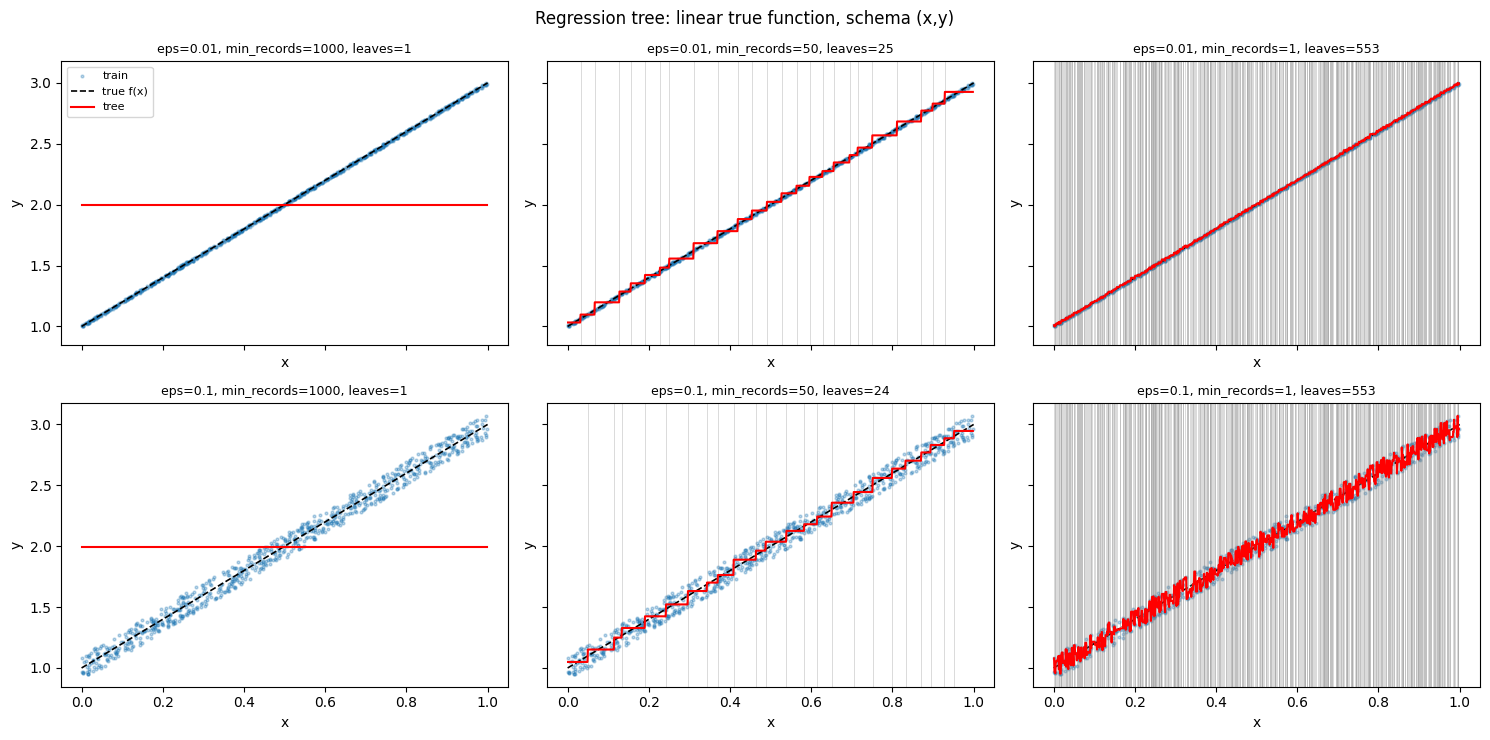

In [11]:
plot_setup('linear', '(x,y)')

### Q9: linear $f(x) = 2x + 1$, schema (x,x²,x³,y)

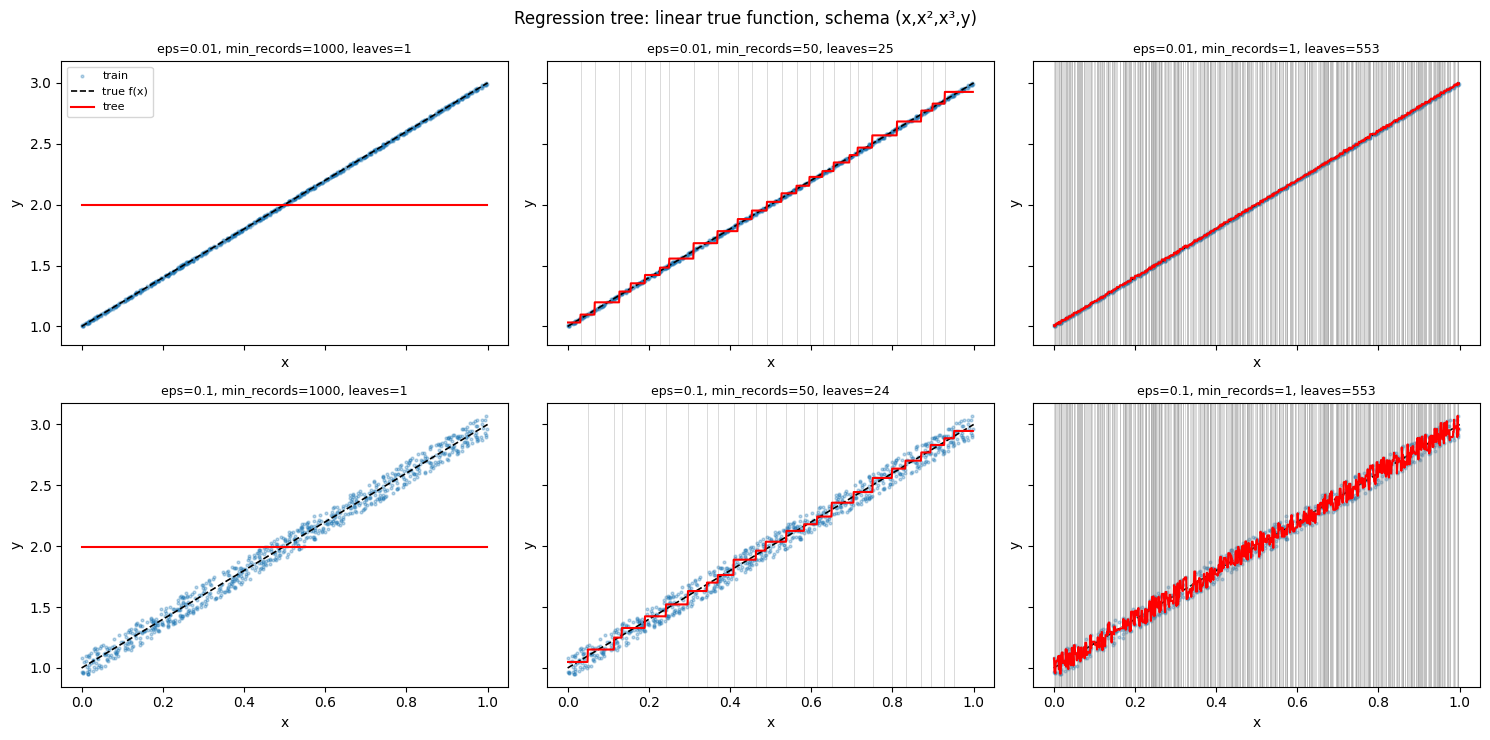

In [12]:
plot_setup('linear', '(x,x²,x³,y)')

### Q9: cubic $f(x) = 0.5x^3 - x^2 + x$, schema (x,y)

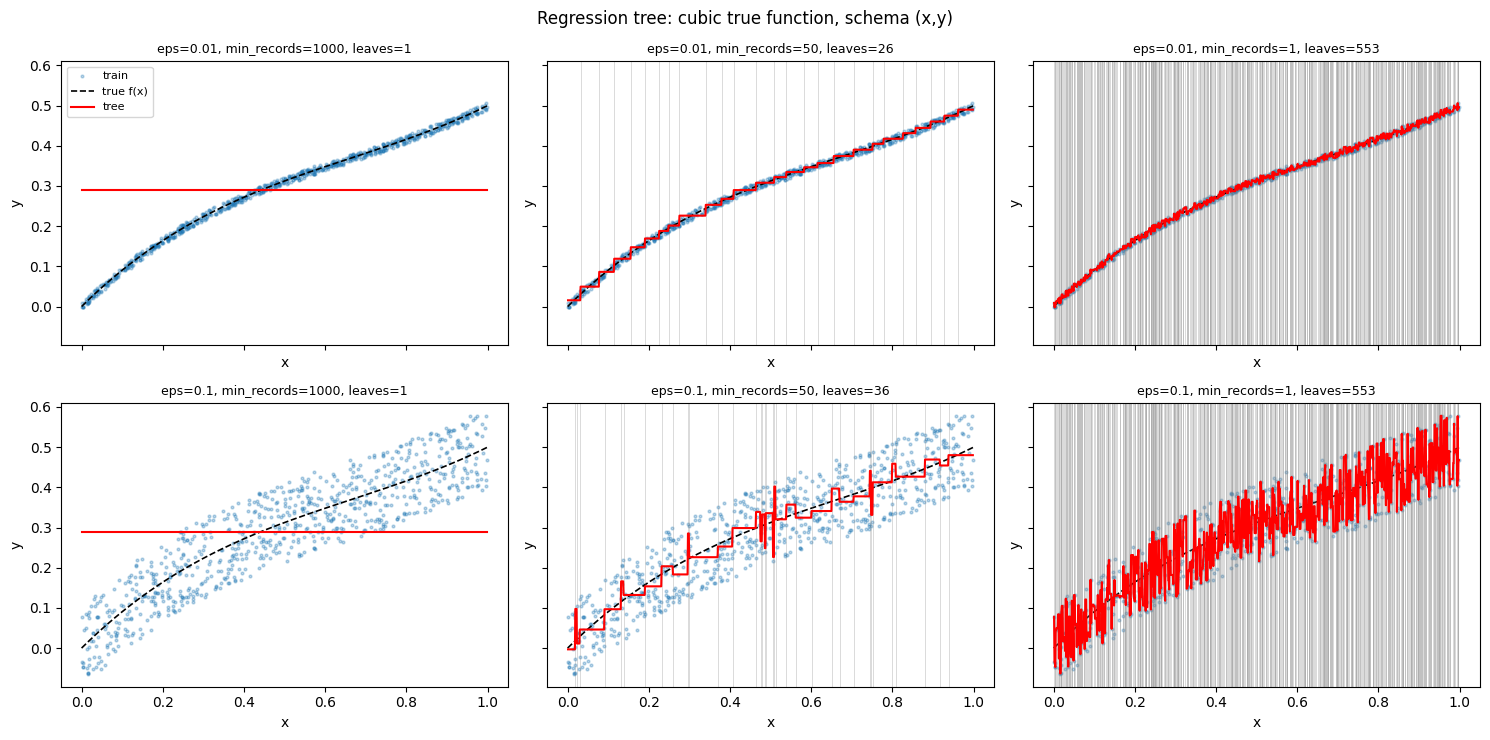

In [13]:
plot_setup('cubic', '(x,y)')

### Q9: cubic $f(x) = 0.5x^3 - x^2 + x$, schema (x,x²,x³,y)

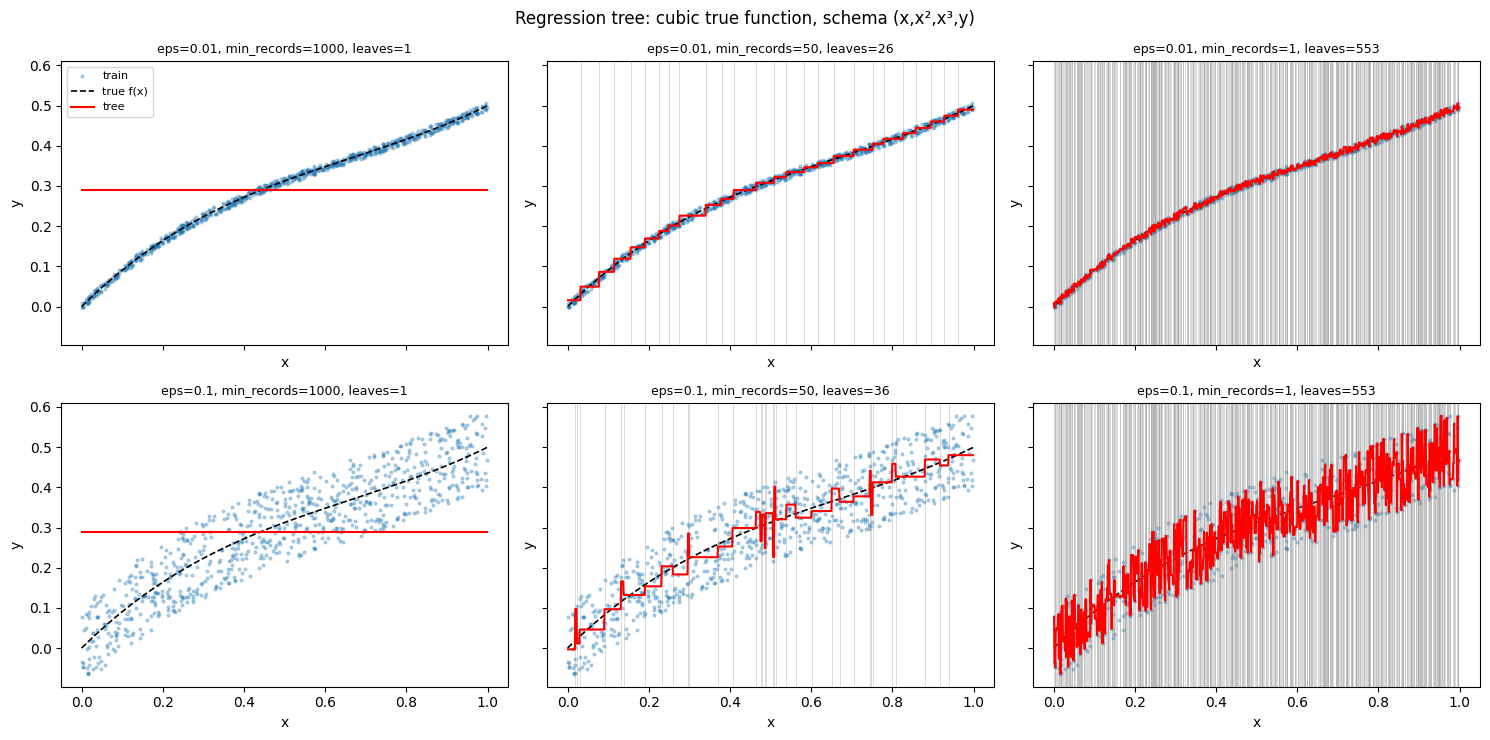

In [14]:
plot_setup('cubic', '(x,x²,x³,y)')

## Q10: Trees vs. linear regression
> *For each input dataset, compare the RMSE of the trees to the corresponding linear models for the same input data. Who wins? (i) Do the extra columns make a difference for the trees? (ii) How many nodes do the trees have and how many records in each of their leaves? Does the tree size make a difference? (iii) Does the noise level have an impact?*

The full results: for every dataset, the linear model on the same columns and each of the three trees.

In [15]:
rows = []
for (fname, eps, sname), (tr, ts) in datasets.items():
    Xtr, ytr = with_ones(tr)
    Xts, yts = with_ones(ts)
    betas = calc_weight(Xtr, ytr)
    rows.append(dict(func=fname, eps=eps, schema=sname, model='linear',
                     train_rmse=rmse(pred(betas, Xtr), ytr), test_rmse=rmse(pred(betas, Xts), yts)))
    for m in min_records_list:
        t = trees[(fname, eps, sname, m)]
        leaves = t.leaf_sizes()
        rows.append(dict(func=fname, eps=eps, schema=sname, model=f'tree m={m}',
                         train_rmse=rmse(t.predict(tr[:, :-1]), ytr), test_rmse=rmse(t.predict(ts[:, :-1]), yts),
                         nodes=len(t.nodes()), leaves=len(leaves),
                         leaf_min=min(leaves), leaf_median=np.median(leaves), leaf_max=max(leaves)))

results = pd.DataFrame(rows).astype({c: 'Int64' for c in ['nodes', 'leaves', 'leaf_min', 'leaf_max']})
pd.set_option('display.float_format', '{:.4f}'.format)
results

,func,eps,schema,model,train_rmse,test_rmse,nodes,leaves,leaf_min,leaf_median,leaf_max
0,linear,0.0100,"(x,y)",linear,0.0058,0.0058,<NA>,<NA>,<NA>,NaN,<NA>
1,linear,0.0100,"(x,y)",tree m=1000,0.5689,0.5911,1,1,800,800.0000,800
2,linear,0.0100,"(x,y)",tree m=50,0.0260,0.0289,49,25,19,30.0000,49
3,linear,0.0100,"(x,y)",tree m=1,0.0034,0.0083,1105,553,1,1.0000,5
4,linear,0.0100,"(x,x²,x³,y)",linear,0.0058,0.0058,<NA>,<NA>,<NA>,NaN,<NA>
5,linear,0.0100,"(x,x²,x³,y)",tree m=1000,0.5689,0.5911,1,1,800,800.0000,800
6,linear,0.0100,"(x,x²,x³,y)",tree m=50,0.0260,0.0289,49,25,19,30.0000,49
7,linear,0.0100,"(x,x²,x³,y)",tree m=1,0.0034,0.0083,1105,553,1,1.0000,5
8,linear,0.1000,"(x,y)",linear,0.0583,0.0574,<NA>,<NA>,<NA>,NaN,<NA>
9,linear,0.1000,"(x,y)",tree m=1000,0.5735,0.5906,1,1,800,800.0000,800


### Who wins?
Test RMSE side by side, with one row per dataset and one column per model:

In [16]:
results.pivot_table(index=['func', 'eps', 'schema'], columns='model', values='test_rmse', sort=False)

model                      linear  tree m=1000  tree m=50  tree m=1
func   eps    schema                                               
linear 0.0100 (x,y)        0.0058       0.5911     0.0289    0.0083
              (x,x²,x³,y)  0.0058       0.5911     0.0289    0.0083
       0.1000 (x,y)        0.0574       0.5906     0.0648    0.0776
              (x,x²,x³,y)  0.0574       0.5906     0.0648    0.0776
cubic  0.0100 (x,y)        0.0234       0.1369     0.0083    0.0078
              (x,x²,x³,y)  0.0058       0.1369     0.0083    0.0078
       0.1000 (x,y)        0.0640       0.1463     0.0610    0.0775
              (x,x²,x³,y)  0.0574       0.1463     0.0610    0.0775

The model that matches the true function wins.
* **Linear true function:** linear regression wins on every dataset (test RMSE 0.0058 vs. 0.0083 for the best tree at ε = 0.01; 0.0574 vs. 0.0648 at ε = 0.1). A tree can only approximate a straight line with steps.
* **Cubic, schema (x,y):** the straight line is the wrong model (0.0234 at ε = 0.01), so the trees win (0.0078 for `min_records=1`). At ε = 0.1 the `min_records=50` tree is also slightly better (0.0610 vs. 0.0640).
* **Cubic, schema (x,x²,x³,y):** linear regression now contains the true model and wins again (0.0058 and 0.0574).

### (i) Do the extra columns make a difference for the trees?
Compare the predictions of the (x,y) tree and the (x,x²,x³,y) tree on the same test x values:

In [17]:
for fname in true_funcs:
    for eps in noise_levels:
        for m in min_records_list:
            p1 = trees[(fname, eps, '(x,y)', m)].predict(datasets[(fname, eps, '(x,y)')][1][:, :-1])
            p3 = trees[(fname, eps, '(x,x²,x³,y)', m)].predict(datasets[(fname, eps, '(x,x²,x³,y)')][1][:, :-1])
            print(f'{fname:6s} eps={eps:<4} m={m:<4}  max |pred diff| = {np.max(np.abs(p1 - p3)):.4f}')

linear eps=0.01 m=1000  max |pred diff| = 0.0000
linear eps=0.01 m=50    max |pred diff| = 0.0000
linear eps=0.01 m=1     max |pred diff| = 0.0000
linear eps=0.1  m=1000  max |pred diff| = 0.0000
linear eps=0.1  m=50    max |pred diff| = 0.0000
linear eps=0.1  m=1     max |pred diff| = 0.0000
cubic  eps=0.01 m=1000  max |pred diff| = 0.0000
cubic  eps=0.01 m=50    max |pred diff| = 0.0000
cubic  eps=0.01 m=1     max |pred diff| = 0.0000
cubic  eps=0.1  m=1000  max |pred diff| = 0.0000
cubic  eps=0.1  m=50    max |pred diff| = 0.0000
cubic  eps=0.1  m=1     max |pred diff| = 0.0000


**No.** The predictions with and without $x^2, x^3$ are identical (max difference 0). On $[0,1]$, $x^2$ and $x^3$ increase with $x$, so "$x^2 \le v$" selects exactly the same records as "$x \le \sqrt{v}$". Every column offers the same candidate partitions, and the tree picks the same splits. Only the linear model benefits from the extra columns.

### (ii) Tree size: nodes and records per leaf
Shown for schema (x,y) only, since (i) shows that the (x,x²,x³,y) trees are identical:

In [18]:
results[(results.model != 'linear') & (results.schema == '(x,y)')][
    ['func', 'eps', 'model', 'nodes', 'leaves', 'leaf_min', 'leaf_median', 'leaf_max', 'test_rmse']]

,func,eps,model,nodes,leaves,leaf_min,leaf_median,leaf_max,test_rmse
1,linear,0.0100,tree m=1000,1,1,800,800.0000,800,0.5911
2,linear,0.0100,tree m=50,49,25,19,30.0000,49,0.0289
3,linear,0.0100,tree m=1,1105,553,1,1.0000,5,0.0083
9,linear,0.1000,tree m=1000,1,1,800,800.0000,800,0.5906
10,linear,0.1000,tree m=50,47,24,16,34.5000,48,0.0648
11,linear,0.1000,tree m=1,1105,553,1,1.0000,5,0.0776
17,cubic,0.0100,tree m=1000,1,1,800,800.0000,800,0.1369
18,cubic,0.0100,tree m=50,51,26,19,29.5000,45,0.0083
19,cubic,0.0100,tree m=1,1105,553,1,1.0000,5,0.0078
25,cubic,0.1000,tree m=1000,1,1,800,800.0000,800,0.1463


* **`min_records=1000`:** 1 node, a single leaf holding all 800 records. It predicts the training mean and is by far the worst (0.59 for linear, 0.14 for cubic).
* **`min_records=50`:** 47–71 nodes and 24–36 leaves of 2–49 records each (median about 30).
* **`min_records=1`:** 1105 nodes and 553 leaves, almost all with 1 record. The largest leaf holds 5 records; x is rounded to 3 decimals, so records can share an x value and no split can separate them.

**Tree size matters.** A 1-leaf tree underfits badly. How large the tree should be depends on the noise, see (iii).

### (iii) Does the noise level have an impact?
Train vs. test RMSE of the trees at both noise levels (schema (x,y)):

In [19]:
results[(results.model != 'linear') & (results.schema == '(x,y)')].pivot_table(
    index=['func', 'model'], columns='eps', values=['train_rmse', 'test_rmse'], sort=False)

train_rmse        test_rmse       
eps                    0.0100 0.1000    0.0100 0.1000
func   model                                         
linear tree m=1000     0.5689 0.5735    0.5911 0.5906
       tree m=50       0.0260 0.0573    0.0289 0.0648
       tree m=1        0.0034 0.0340    0.0083 0.0776
cubic  tree m=1000     0.1300 0.1438    0.1369 0.1463
       tree m=50       0.0075 0.0544    0.0083 0.0610
       tree m=1        0.0034 0.0340    0.0078 0.0775

**Yes.**
* At ε = 0.01 the largest tree is the best tree (0.0083 / 0.0078), because there is hardly any noise to memorize.
* At ε = 0.1 the `min_records=1` tree memorizes the noise: train RMSE 0.034, test RMSE 0.0776. That is close to $\sqrt{2}\,\sigma = 0.082$, the error of predicting each test point with one noisy neighbor. The `min_records=50` tree is better (0.0648 / 0.0610).
* The noise also sets a floor. At ε = 0.1 no model gets below the noise standard deviation $0.1/\sqrt{3} \approx 0.058$.

## Q11: Overfitting study
> *Generate 200 data records using f(x) = sin(2πx) and noise level 0.2. Train trees for min_records set to 2, 4, 8, 16, 32, 64, 128, and 256; and create a plot with min_records on the x-axis vs training RMSE and test RMSE on the y-axis. Which tree would you select as the best model? Which one has the highest bias? Which one has the highest variance?*

Schema $(x, y)$ with the same fixed 80/20 split, so 160 training and 40 test records.

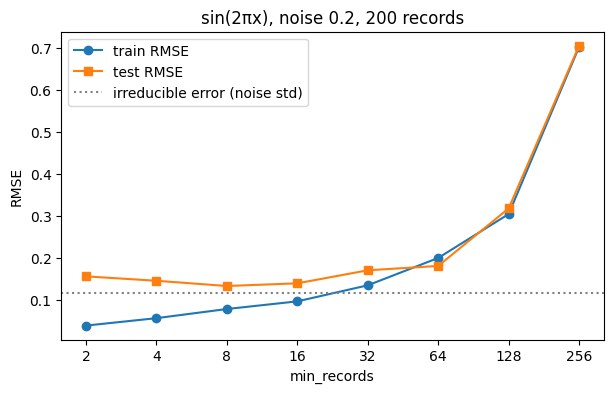

,min_records,train_rmse,test_rmse,leaves
0,2,0.0388,0.1560,143
1,4,0.0564,0.1456,82
2,8,0.0782,0.1331,41
3,16,0.0965,0.1394,19
4,32,0.1347,0.1705,9
5,64,0.1999,0.1808,5
6,128,0.3045,0.3180,2
7,256,0.7029,0.7059,1


In [20]:
f_sin = lambda x: np.sin(2 * np.pi * x)
random.seed(SEED)
tr_sin, ts_sin = split_train_test(np.array(generate_noisy_dataset([], f_sin, [0.0, 1.0], 200, 0.2)))

mr_values = [2, 4, 8, 16, 32, 64, 128, 256]
sin_trees = {m: RegressionTree().fit(tr_sin, m) for m in mr_values}
sin_train = [rmse(sin_trees[m].predict(tr_sin[:, :-1]), tr_sin[:, -1]) for m in mr_values]
sin_test = [rmse(sin_trees[m].predict(ts_sin[:, :-1]), ts_sin[:, -1]) for m in mr_values]

plt.figure(figsize=(7, 4))
plt.plot(mr_values, sin_train, 'o-', label='train RMSE')
plt.plot(mr_values, sin_test, 's-', label='test RMSE')
plt.axhline(0.2 / math.sqrt(3), color='gray', ls=':', label='irreducible error (noise std)')
plt.xscale('log', base=2)
plt.xticks(mr_values, mr_values)
plt.xlabel('min_records')
plt.ylabel('RMSE')
plt.title('sin(2πx), noise 0.2, 200 records')
plt.legend()
plt.show()

pd.DataFrame({'min_records': mr_values, 'train_rmse': sin_train, 'test_rmse': sin_test,
              'leaves': [len(sin_trees[m].leaf_sizes()) for m in mr_values]})

The highest-variance tree, the best tree, and the highest-bias tree:

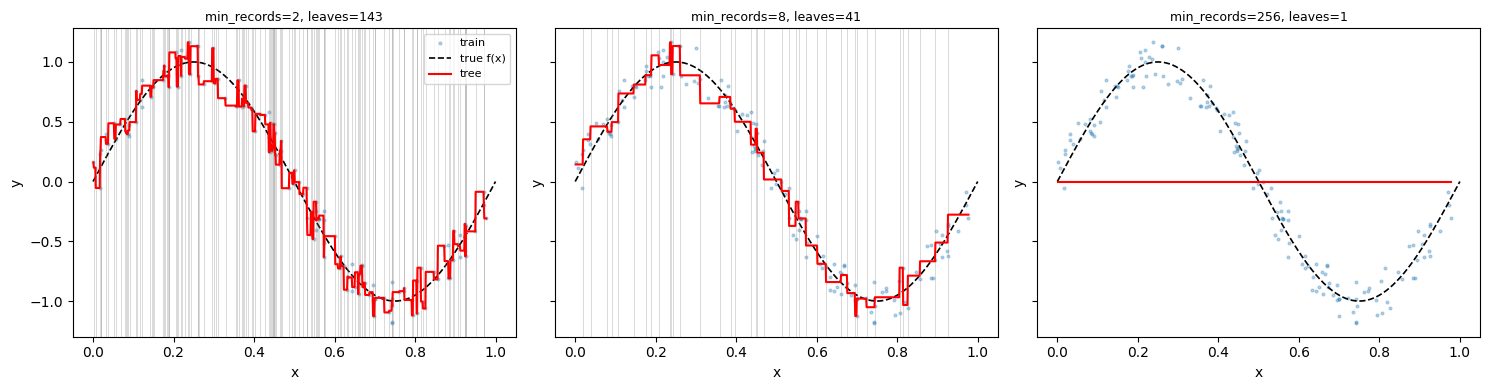

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
best_m = mr_values[int(np.argmin(sin_test))]
for ax, m in zip(axes, [2, best_m, 256]):
    plot_fit(ax, sin_trees[m], tr_sin, f_sin, [], f'min_records={m}, leaves={len(sin_trees[m].leaf_sizes())}')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Training RMSE** rises steadily with `min_records`, because smaller trees fit the training data less closely. **Test RMSE** is U-shaped: first overfitting, then underfitting.

* **Best model:** `min_records=8` (41 leaves) has the lowest test RMSE, 0.133. That is close to the irreducible error $0.2/\sqrt{3} \approx 0.115$.
* **Highest bias:** `min_records=256`. It is larger than the 160 training records, so the tree is a single leaf that predicts the mean. The sine is ignored completely, and train and test RMSE are both about 0.70.
* **Highest variance:** `min_records=2` (143 leaves). Its training RMSE of 0.039 is far below the noise level, which means it fits the noise. It has the largest gap between train and test error (0.039 vs. 0.156).

## Q12: Hyper-parameters
> *Explain briefly which, if any, hyper-parameters your linear regression and your tree algorithm support.*

* **Linear regression:** the only hyper-parameter is the **input schema**, meaning which extra columns $f_1(x), \dots, f_d(x)$ (such as monomials up to some degree) are added. The weights come from the closed form $(X^TX)^{-1}X^TY$, so there is no learning rate, number of iterations, or regularization strength.
* **Regression tree:** the main hyper-parameter is **`min_records`**, the minimum number of records a node needs before it may split. It controls tree size, and therefore the trade-off between bias (large values) and variance (small values). The input schema can also be seen as one, but for monotone extra columns like $x^2$ and $x^3$ on $[0, 1]$ it does not change the tree (see Q10 (i)). The impurity measure (SSE) and the split rule ("≤ a distinct value") are fixed design choices and cannot be tuned.